## Nonlinear equalization based on Memory Polynomials applied to the experimental data

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from datetime               import datetime
from scipy.signal           import hilbert, firwin, welch
from scipy.constants        import pi
from scipy.io               import loadmat

from optic.comm.metrics     import fastBERcalc, calcEVM
from optic.utils            import parameters, dBm2W
from optic.dsp.core         import pnorm, signal_power, upsample, decimate, finddelay, firFilter, clockSamplingInterp
from optic.plot             import pconst

from proc_ofdm              import save_OFDM, tx_OFDM, rx_OFDM, demodulateOFDM_v2, mmse_equalizer, plot_const

In [2]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado"
file_path    = project_path + r"\DPD"
sys.path.append(project_path)
sys.path.append(file_path)

from DPD_utils.MP_tools     import MP_filter, LS_solver, MP_training

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### Parameters initialization

In [4]:
paramOFDM = parameters()

# Modulation parameters
paramOFDM.mode     = "ARoF"
paramOFDM.modOrder = 64                # Modulation order
paramOFDM.modType  = 'qam'             # Modulation type
paramOFDM.numOFDMframes = 10           # Number of ofdm symbols generated

paramOFDM.bw  = 100e6                  # Channel bandwidth
paramOFDM.scs = 30e3                   # Subcarrier spacing

if paramOFDM.bw == 100e6 and paramOFDM.scs == 30e3:
    paramOFDM.Nfft = 2**12

elif paramOFDM.bw == 50e6 and paramOFDM.scs == 30e3:
    paramOFDM.Nfft  = 2**12

elif paramOFDM.bw == 10e6 and paramOFDM.scs == 30e3:
    paramOFDM.Nfft = 2**9

elif paramOFDM.bw == 400e6 and paramOFDM.scs == 480e3:
    paramOFDM.Nfft = 2**11

elif paramOFDM.bw == 100e6 and paramOFDM.scs == 480e3:
    paramOFDM.Nfft = 2**12

elif paramOFDM.bw == 400e6 and paramOFDM.scs == 1e6:
    paramOFDM.Nfft = 2**11

else:
    print("Check parameters for error in Nfft")

paramOFDM.G    = 32                    # Cyclic prefix length
paramOFDM.hermitSymmetry = False       # If true, the OFDM signal respects the Hermitian symmetry
paramOFDM.returnChannel  = False       # If true, the channel estimated response is returned

paramOFDM.saveTx       = False          # If true, the transmitted signal information is saved in a .mat file
paramOFDM.awg_model    = "Tektronix"   # "Keysight" "Tektronix" "R&S"
paramOFDM.awg_filepath = r"C:\Users\PC\Documents\Mestrado\DPD"
paramOFDM.tx_info_path = r"C:\Users\PC\Documents\Mestrado\DPD"
paramOFDM.seed = 3

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

#
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz

# RF carrier frequency
paramOFDM.fc = 3.55e9

# Devices sampling frequencies
paramOFDM.Fawg = 25e9
paramOFDM.Fdso = 20e9
paramOFDM.SpS_out = 4  # Samples per symbols after downsampling

sigTx_RF, sigTx_BB, symbTx = tx_OFDM(paramOFDM)

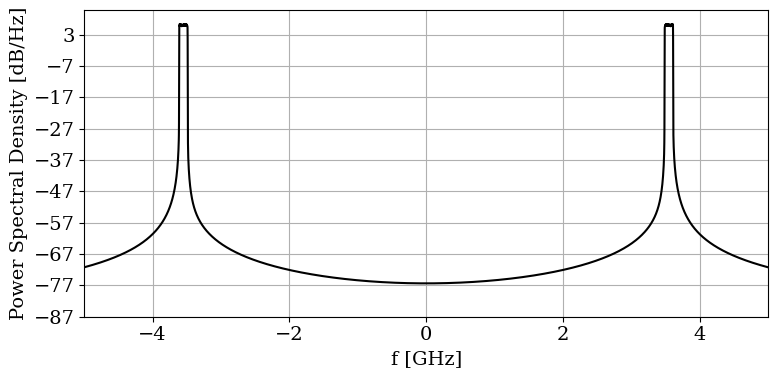

In [5]:
fig, axs = plt.subplots(figsize = (8, 4))
axs.psd(sigTx_RF, Fs = paramOFDM.Fawg/1e9, NFFT = 16*1024, color = "k",sides = 'twosided', label = "sigOFDM-RF")
axs.set_xlabel("f [GHz]")
axs.set_ylabel("Power Spectral Density [dB/Hz]")
axs.set_xlim(-5, 5)
axs.grid(True)
plt.tight_layout()

### Channel with delay and resampling to Fdso sampling rate

In [19]:
def calc_nleq(sigRef, sigIn, numOFDMframes_rx, paramOFDM, paramNLEQ):
    # Time synchronization
    delay = finddelay(sigIn, sigRef)
    sigIn = np.roll(sigIn, -delay)
    
    samples_per_frame = paramOFDM.SpS_out * (paramOFDM.Nfft + paramOFDM.G)
    
    sigRef_par = np.reshape(sigRef[0:numOFDMframes_rx*samples_per_frame], (numOFDMframes_rx, samples_per_frame))        
    sigIn_par  = np.reshape(sigIn[0:numOFDMframes_rx*samples_per_frame], (numOFDMframes_rx, samples_per_frame))

    # Phase correction
    for frame in range(numOFDMframes_rx):
        rot   = np.mean(sigRef_par[frame,:]/sigIn_par[frame, :])
        sigIn_par[frame, :] = rot/np.abs(rot)*sigIn_par[frame, :]
    
    sigIn = sigIn_par.ravel()
    w_ila, errSq = MP_training(sigRef, paramNLEQ, sigIn)
    
    sig_nleq = MP_filter(sigIn, np.conj(w_ila).reshape((paramNLEQ.P, paramNLEQ.M)))
    
    # Low-pass filtering
    bw = 75e6
    hlp = firwin(4096, bw, fs = paramOFDM.Fawg/(paramOFDM.SpS/paramOFDM.SpS_out))
    sigRx_nleq = firFilter(hlp, sig_nleq)
    sigRx_nleq -= np.mean(sigRx_nleq)
    
    # OFDM demodulation
    symbRx_OFDM = sigRx_nleq[0::paramOFDM.SpS_out].copy()
    symbRx_nleq = demodulateOFDM_v2(symbRx_OFDM.copy(), paramOFDM)

    return sigRx_nleq, sig_nleq, symbRx_nleq

In [20]:
att_sweep = np.arange(0, 21, 2)

EVM_sweep = np.zeros(att_sweep.size)
BER_sweep = np.zeros(att_sweep.size)

EVM_nleq_sweep = np.zeros(att_sweep.size)
BER_nleq_sweep = np.zeros(att_sweep.size)

Rs = paramOFDM.Nfft * paramOFDM.scs
SpS_in  = paramOFDM.SpS
SpS_out = paramOFDM.SpS_out

In [21]:
# NLEQ parameters
paramNLEQ = parameters()
paramNLEQ.M = 8
paramNLEQ.P = 4

paramNLEQ.N = 20_000
paramNLEQ.numIter = 3

paramNLEQ.mu  = 1e-3
paramNLEQ.lbd = 0.9999
paramNLEQ.S   = np.eye(paramNLEQ.P*paramNLEQ.M, dtype = complex)*5e-2

paramNLEQ.alg = "RLS"
paramNLEQ.a_kl = np.zeros((1, 1))
paramNLEQ.directLearn = False

paramNLEQ.pgrsBar    = False
paramNLEQ.showMSE    = False
paramNLEQ.storeCoeff = False

In [22]:
for i, att in enumerate(att_sweep):
    filename = rf"C:\Users\PC\Documents\Mestrado\DPD\Cooperacao_KTH\Dados_experimentais\att_{att}dB\dso_data1.mat"
    sigRx_exp = loadmat(filename)["dso_data"].ravel()
    
    sigRx, sigRx_BB, symbRx = rx_OFDM(sigRx_exp, sigTx_BB, paramOFDM, plot = False)
    numOFDMframes_rx = symbRx.size // Ni
    
    samples_per_frame_in  = SpS_in  * (paramOFDM.Nfft + paramOFDM.G)
    samples_per_frame_out = SpS_out * (paramOFDM.Nfft + paramOFDM.G)

    # Resampling of input and output signal
    sigRef = clockSamplingInterp(sigTx_BB[0:numOFDMframes_rx*samples_per_frame_in].reshape(-1, 1), paramOFDM.Fawg, paramOFDM.Fawg/(SpS_in/SpS_out)).ravel()
    sigIn  = sigRx_BB[0:numOFDMframes_rx*samples_per_frame_out]

    # Nonlinear equalization based on memory polynomials
    sigRx_nleq, sig_nleq, symbRx_nleq = calc_nleq(sigRef, sigIn, numOFDMframes_rx, paramOFDM, paramNLEQ)
    
    # Metrics calculation
    discard = 500
    index = np.arange(0, symbRx.size - discard)
    
    # Without NLEQ
    BER, _, SNR = fastBERcalc(symbRx[index], symbTx[0:Ni*numOFDMframes_rx][index], paramOFDM.modOrder, paramOFDM.modType)
    EVM = np.sqrt(calcEVM(symbRx[index], paramOFDM.modOrder, paramOFDM.modType, symbTx[0:Ni*numOFDMframes_rx][index]))*100
    
    # With NLEQ
    BER_nleq, _, SNR_nleq = fastBERcalc(symbRx_nleq[index], symbTx[0:Ni*numOFDMframes_rx][index], paramOFDM.modOrder, paramOFDM.modType)
    EVM_nleq = np.sqrt(calcEVM(symbRx_nleq[index], paramOFDM.modOrder, paramOFDM.modType, symbTx[0:Ni*numOFDMframes_rx][index]))*100
    
    BER_sweep[i]  = BER[0]
    EVM_sweep[i]  = EVM[0]
    
    BER_nleq_sweep[i] = BER_nleq[0]
    EVM_nleq_sweep[i] = EVM_nleq[0]
        
    print(f"\n- Att. = {att} dB:")
    print(f"Without NLEQ: BER = {BER[0]:.6f}, EVM = {EVM[0]:.4f} %")
    print(f"With NLEQ: BER = {BER_nleq[0]:.6f}, EVM = {EVM_nleq[0]:.4f} %")
    
    # Normalization for plotting
    symbTx = pnorm(symbTx)
    symbRx = pnorm(symbRx)
    symbRx_nleq = pnorm(symbRx_nleq)

    plot_const([symbRx, symbRx_nleq, symbTx], ["b", "r", "k"], index, save = True, show = False, filename = fr"C:\Users\PC\Documents\Mestrado\DPD\Cooperacao_KTH\Results_MP\constelacao_att_{att}dB.png")


- Att. = 0 dB:
Without NLEQ: BER = 0.006831, EVM = 9.5319 %
With NLEQ: BER = 0.000006, EVM = 4.5656 %

- Att. = 2 dB:
Without NLEQ: BER = 0.000178, EVM = 6.0778 %
With NLEQ: BER = 0.000000, EVM = 4.3675 %

- Att. = 4 dB:
Without NLEQ: BER = 0.000071, EVM = 5.3979 %
With NLEQ: BER = 0.000030, EVM = 4.3294 %

- Att. = 6 dB:
Without NLEQ: BER = 0.000000, EVM = 4.8878 %
With NLEQ: BER = 0.000012, EVM = 4.5700 %

- Att. = 8 dB:
Without NLEQ: BER = 0.000018, EVM = 4.7988 %
With NLEQ: BER = 0.000018, EVM = 4.6276 %

- Att. = 10 dB:
Without NLEQ: BER = 0.000445, EVM = 6.4989 %
With NLEQ: BER = 0.000320, EVM = 6.2125 %

- Att. = 12 dB:
Without NLEQ: BER = 0.001026, EVM = 7.2350 %
With NLEQ: BER = 0.000913, EVM = 7.1247 %

- Att. = 14 dB:
Without NLEQ: BER = 0.009279, EVM = 10.0011 %
With NLEQ: BER = 0.010400, EVM = 10.2267 %

- Att. = 16 dB:
Without NLEQ: BER = 0.035030, EVM = 14.4298 %
With NLEQ: BER = 0.034544, EVM = 14.2750 %

- Att. = 18 dB:
Without NLEQ: BER = 0.068501, EVM = 18.7094 %
Wi

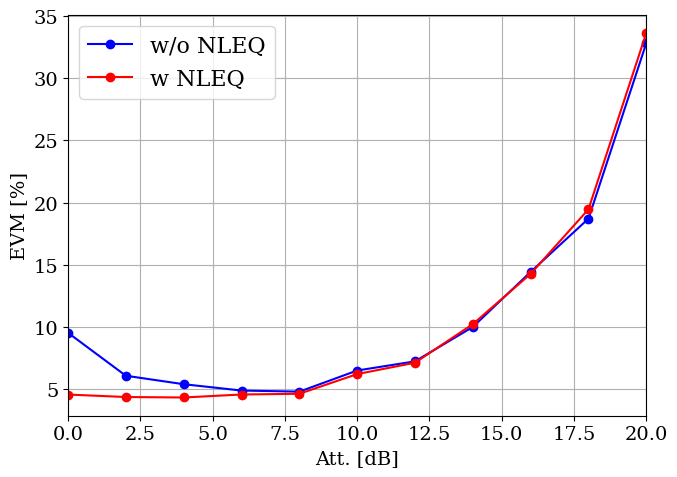

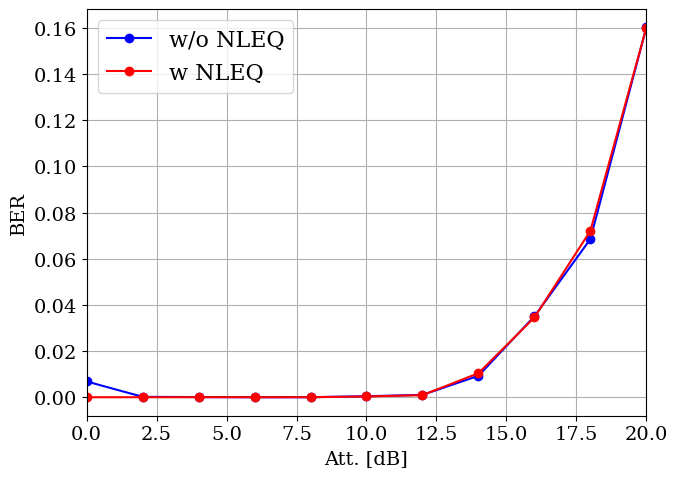

In [23]:
plt.figure(figsize = (7, 5))
plt.plot(att_sweep, EVM_sweep, "-o", color = "b", label = "w/o NLEQ")
plt.plot(att_sweep, EVM_nleq_sweep, "-o", color = "r", label = "w NLEQ")
plt.xlim(np.min(att_sweep), np.max(att_sweep))
plt.xlabel("Att. [dB]")
plt.ylabel("EVM [%]")
plt.grid()
plt.legend(fontsize = 16)
plt.tight_layout()

plt.figure(figsize = (7, 5))
plt.plot(att_sweep, BER_sweep, "-o", color = "b", label = "w/o NLEQ")
plt.plot(att_sweep, BER_nleq_sweep, "-o", color = "r", label = "w NLEQ")
plt.xlim(np.min(att_sweep), np.max(att_sweep))
plt.xlabel("Att. [dB]")
plt.ylabel("BER")
plt.grid()
plt.legend(fontsize = 16)
plt.tight_layout()